In [ ]:
from sklearn.datasets import fetch_openml

# Load German Credit dataset from OpenML

creditg = fetch_openml(name='credit-g', as_frame=True)
# https://www.openml.org/d/31

print("Shape:", creditg.frame.shape)
print("Columns:", list(creditg.frame.columns))


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)


Shape: (1000, 21)
Columns: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']


In [ ]:
# Target class distribution
print(creditg.frame['class'].value_counts())
print()

# Class percentages
print(creditg.frame['class'].value_counts(normalize=True) * 100)
print()

# Numeric features summary
print(creditg.frame.describe())
print()

# Check for missing values
print(creditg.frame.isnull().sum().sum(), "total missing values")


class
good    700
bad     300
Name: count, dtype: int64

class
good    70.0
bad     30.0
Name: proportion, dtype: float64

          duration  credit_amount  installment_commitment  residence_since  \
count  1000.000000    1000.000000             1000.000000      1000.000000   
mean     20.903000    3271.258000                2.973000         2.845000   
std      12.058814    2822.736876                1.118715         1.103718   
min       4.000000     250.000000                1.000000         1.000000   
25%      12.000000    1365.500000                2.000000         2.000000   
50%      18.000000    2319.500000                3.000000         3.000000   
75%      24.000000    3972.250000                4.000000         4.000000   
max      72.000000   18424.000000                4.000000         4.000000   

               age  existing_credits  num_dependents  
count  1000.000000       1000.000000     1000.000000  
mean     35.546000          1.407000        1.155000  
std      

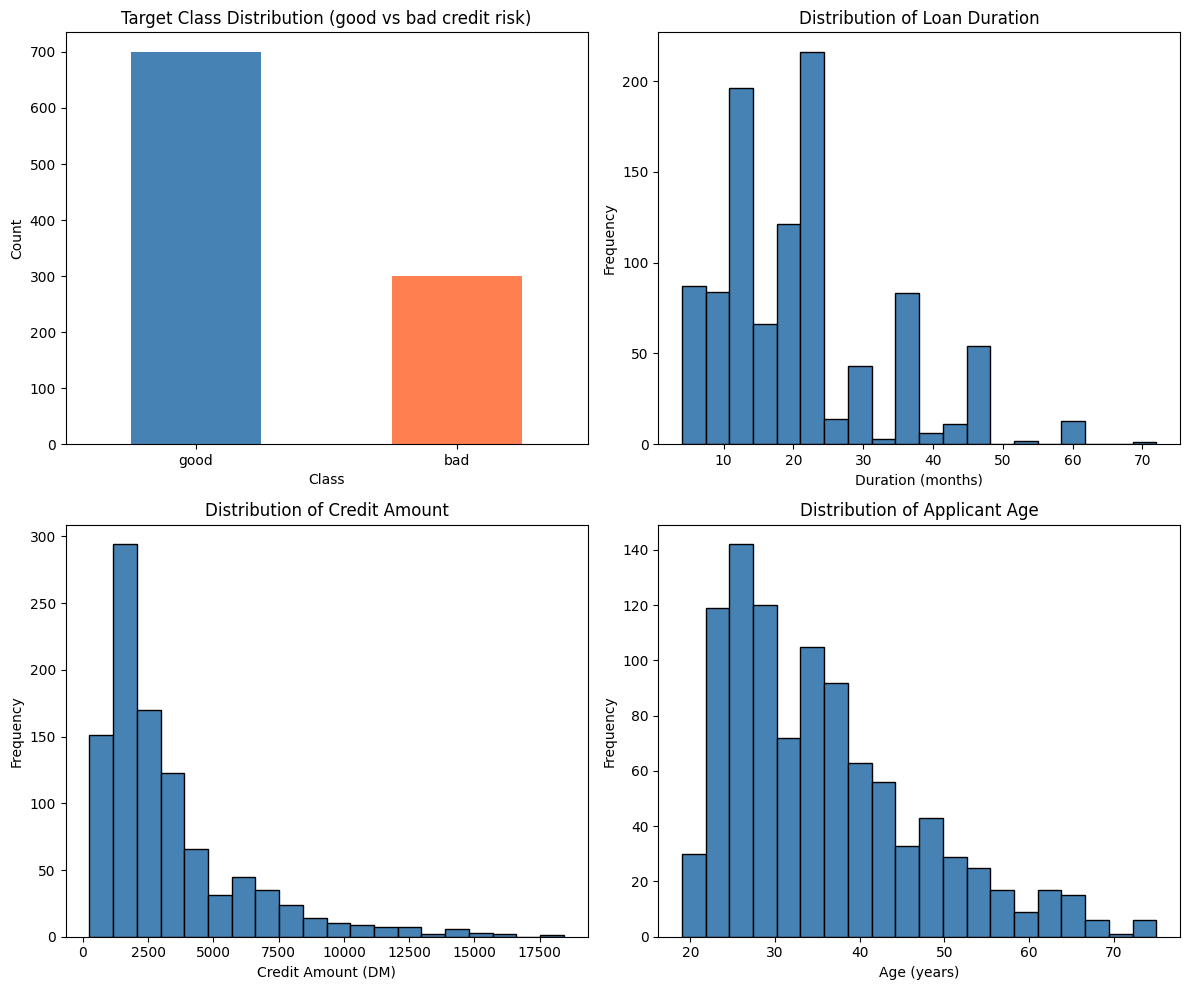

In [ ]:
import matplotlib.pyplot as plt

# Set up a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Target class distribution
creditg.frame['class'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'coral'])
axes[0, 0].set_title('Target Class Distribution (good vs bad credit risk)')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# Plot 2: Distribution of loan duration in months
creditg.frame['duration'].plot(kind='hist', bins=20, ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Distribution of Loan Duration')
axes[0, 1].set_xlabel('Duration (months)')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Distribution of credit amount
creditg.frame['credit_amount'].plot(kind='hist', bins=20, ax=axes[1, 0], color='steelblue', edgecolor='black')
axes[1, 0].set_title('Distribution of Credit Amount')
axes[1, 0].set_xlabel('Credit Amount (DM)')
axes[1, 0].set_ylabel('Frequency')

# Plot 4: Distribution of age
creditg.frame['age'].plot(kind='hist', bins=20, ax=axes[1, 1], color='steelblue', edgecolor='black')
axes[1, 1].set_title('Distribution of Applicant Age')
axes[1, 1].set_xlabel('Age (years)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


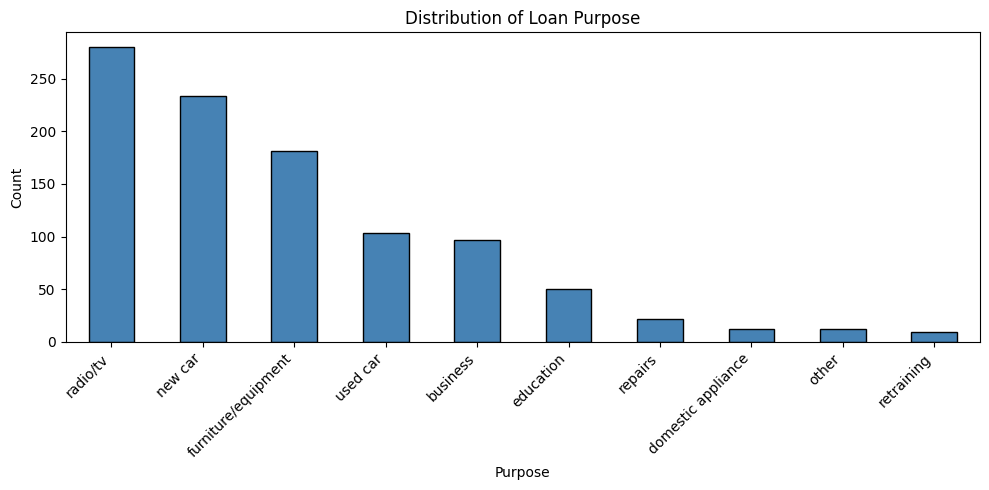

In [ ]:
# Bar chart for categorical feature
fig, ax = plt.subplots(figsize=(10, 5))
creditg.frame['purpose'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribution of Loan Purpose')
ax.set_xlabel('Purpose')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Use dropna() to remove rows with missing data
dataset = creditg.frame.dropna()
print(dataset.shape[0])

# Identify the target and predictor columns
target_column = 'class'

# List the categorical input columns
categorical_cols = ['checking_status', 'credit_history', 'purpose', 'savings_status',
                    'employment', 'personal_status', 'other_parties',
                    'property_magnitude', 'other_payment_plans', 'housing',
                    'job', 'own_telephone', 'foreign_worker']

# List the numeric input columns
numeric_cols = ['duration', 'credit_amount', 'installment_commitment',
                'residence_since', 'age', 'existing_credits', 'num_dependents']

# Categorical input columns
print(len(categorical_cols))

# Numeric input columns
print(len(numeric_cols))

# Target column
print(target_column)


1000
13
7
class


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode each categorical column

for col in categorical_cols:
    oe = OneHotEncoder()
    oe_results = oe.fit_transform(dataset[[col]])
    # Build new column names like "checking_status_<0", "checking_status_no checking", etc.
    new_col_names = [f"{col}_{cat}" for cat in oe.categories_[0]]
    encoded_df = pd.DataFrame(oe_results.toarray(), columns=new_col_names, index=dataset.index)
    dataset = dataset.join(encoded_df)

# Drop the original categorical columns now that they've been encoded
dataset = dataset.drop(columns=categorical_cols)

# Shape after one-hot encoding
print(dataset.shape)

# First few new column names
print(list(dataset.columns[:10]))


(1000, 62)
['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'class', 'checking_status_0<=X<200', 'checking_status_<0']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode the target column from "good"/"bad" strings to integers
le = LabelEncoder()
dataset['class'] = le.fit_transform(dataset['class'])

# Target classes
print(list(le.classes_))

# First 10 encoded target values
print(dataset['class'].values[:10].tolist())

# Encoded class distribution
print()
print(dataset['class'].value_counts())


['bad', 'good']
[1, 0, 1, 1, 0, 1, 1, 1, 1, 0]

class
1    700
0    300
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Separate predictors (X) and target (y)
X = dataset.drop(columns=['class']).values
y = dataset['class'].values

# 70/30 split, with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train class distribution:", np.bincount(y_train))
print("y_test class distribution:", np.bincount(y_test))


X_train shape: (700, 61)
X_test shape: (300, 61)
y_train class distribution: [209 491]
y_test class distribution: [ 91 209]


In [ ]:
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Baseline SVM with default settings (kernel='rbf', decision_function_shape='ovr')
svm_baseline = svm.SVC()
svm_baseline.fit(X_train, y_train)

# Predict on both train and test
pred_train = svm_baseline.predict(X_train)
pred_test = svm_baseline.predict(X_test)



print("Training accuracy:", accuracy_score(y_train, pred_train))
print("Testing accuracy:", accuracy_score(y_test, pred_test))
print()

# Training confusion matrix
print(confusion_matrix(y_train, pred_train))
print()

# Testing confusion matrix
print(confusion_matrix(y_test, pred_test))
print()

# Testing classification report
print(classification_report(y_test, pred_test, target_names=['bad', 'good']))


Training accuracy: 0.7085714285714285
Testing accuracy: 0.7133333333333334

[[ 17 192]
 [ 12 479]]

[[  5  86]
 [  0 209]]

              precision    recall  f1-score   support

         bad       1.00      0.05      0.10        91
        good       0.71      1.00      0.83       209

    accuracy                           0.71       300
   macro avg       0.85      0.53      0.47       300
weighted avg       0.80      0.71      0.61       300



In [ ]:
# Try multiple combinations of kernel and decision_function_shape
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
shapes = ['ovo', 'ovr']

results = []

for kernel in kernels:
    for shape in shapes:
        model = svm.SVC(kernel=kernel, decision_function_shape=shape)
        model.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))

        # Also compute recall for the "bad" class (encoded as 0)
        from sklearn.metrics import recall_score
        bad_recall = recall_score(y_test, model.predict(X_test), pos_label=0)

        results.append({
            'kernel': kernel,
            'shape': shape,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'bad_recall': bad_recall
        })
        print(f"kernel={kernel:8s} shape={shape}  train_acc={train_acc:.4f}  test_acc={test_acc:.4f}  bad_recall={bad_recall:.4f}")

print()
print("Summary table:")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


kernel=linear   shape=ovo  train_acc=0.7714  test_acc=0.7400  bad_recall=0.3736
kernel=linear   shape=ovr  train_acc=0.7714  test_acc=0.7400  bad_recall=0.3736
kernel=rbf      shape=ovo  train_acc=0.7086  test_acc=0.7133  bad_recall=0.0549
kernel=rbf      shape=ovr  train_acc=0.7086  test_acc=0.7133  bad_recall=0.0549
kernel=poly     shape=ovo  train_acc=0.7043  test_acc=0.7000  bad_recall=0.0110
kernel=poly     shape=ovr  train_acc=0.7043  test_acc=0.7000  bad_recall=0.0110
kernel=sigmoid  shape=ovo  train_acc=0.6229  test_acc=0.6567  bad_recall=0.3846
kernel=sigmoid  shape=ovr  train_acc=0.6229  test_acc=0.6567  bad_recall=0.3846

Summary table:
 kernel shape  train_acc  test_acc  bad_recall
 linear   ovo   0.771429  0.740000    0.373626
 linear   ovr   0.771429  0.740000    0.373626
    rbf   ovo   0.708571  0.713333    0.054945
    rbf   ovr   0.708571  0.713333    0.054945
   poly   ovo   0.704286  0.700000    0.010989
   poly   ovr   0.704286  0.700000    0.010989
sigmoid   ovo  

In [ ]:
# Train the best model (linear kernel) and analyze in detail
best_model = svm.SVC(kernel='linear', decision_function_shape='ovo')
best_model.fit(X_train, y_train)

pred_train_best = best_model.predict(X_train)
pred_test_best = best_model.predict(X_test)



print("Training accuracy:", accuracy_score(y_train, pred_train_best))
print("Test accuracy:", accuracy_score(y_test, pred_test_best))
print()

# Training set

# Confusion matrix
print(confusion_matrix(y_train, pred_train_best))
print()

# Classification report
print(classification_report(y_train, pred_train_best, target_names=['bad', 'good']))

#Test set

# Confusion matrix
print(confusion_matrix(y_test, pred_test_best))
print()

# Classification report
print(classification_report(y_test, pred_test_best, target_names=['bad', 'good']))

# Model properties

# Number of support vectors
print(best_model.n_support_)

# Total support vectors
print(sum(best_model.n_support_))

# Number of features
print(best_model.n_features_in_)

# Number of classes
print(len(best_model.classes_))

Training accuracy: 0.7714285714285715
Test accuracy: 0.74

[[ 88 121]
 [ 39 452]]

              precision    recall  f1-score   support

         bad       0.69      0.42      0.52       209
        good       0.79      0.92      0.85       491

    accuracy                           0.77       700
   macro avg       0.74      0.67      0.69       700
weighted avg       0.76      0.77      0.75       700

[[ 34  57]
 [ 21 188]]

              precision    recall  f1-score   support

         bad       0.62      0.37      0.47        91
        good       0.77      0.90      0.83       209

    accuracy                           0.74       300
   macro avg       0.69      0.64      0.65       300
weighted avg       0.72      0.74      0.72       300

[139 140]
279
61
2


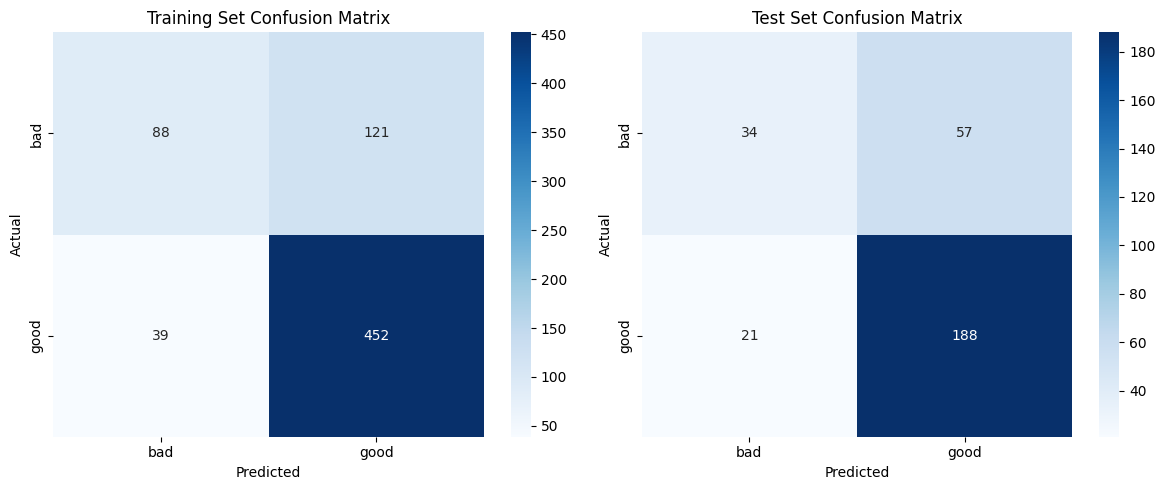

In [ ]:
import seaborn as sns

# Re-fit the best model
best_model = svm.SVC(kernel='linear', decision_function_shape='ovo')
best_model.fit(X_train, y_train)
pred_train = best_model.predict(X_train)
pred_test = best_model.predict(X_test)

# Build the two confusion matrices
cm_train = confusion_matrix(y_train, pred_train)
cm_test = confusion_matrix(y_test, pred_test)

# Plot them side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['bad', 'good'], yticklabels=['bad', 'good'], ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['bad', 'good'], yticklabels=['bad', 'good'], ax=axes[1])
axes[1].set_title('Test Set Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()